# Qwen3-1.7B SDXL Prompt Enhancer

Воспроизводимый Colab-ноутбук для дообучения `Qwen/Qwen3-1.7B` под задачу:

- вход: естественный запрос пользователя на русском языке
- выход: полноценный английский `SDXL` prompt без `<think>` и без пояснений

Pipeline:
1. установка окружения
2. загрузка базовой модели Qwen3-1.7B
3. подготовка `train / eval / test`
4. анализ датасета и визуализации
5. QLoRA-обучение с `assistant-only loss`
6. ручной benchmark
7. сравнение `base` vs `finetuned` на `eval` и `test`
8. сохранение артефактов и метрик

In [1]:
# =========================
# 1. установка зависимостей
# =========================

!pip install -q --no-cache-dir \
  transformers==4.51.3 \
  accelerate==1.6.0 \
  datasets==3.5.0 \
  peft==0.15.2 \
  bitsandbytes==0.49.2 \
  huggingface_hub==0.34.4 \
  evaluate==0.4.3 \
  rouge_score==0.1.2 \
  sacrebleu==2.5.1 \
  bert-score==0.3.13 \
  matplotlib==3.10.1 \
  pandas==2.2.2 \
  seaborn==0.13.2 \
  sentencepiece==0.2.0 \
  safetensors==0.5.3

print("Dependencies installed.")

Dependencies installed.


In [7]:
# =========================
# 2. установка BASE MODEL
# =========================

from huggingface_hub import snapshot_download

MODEL_ID = "Qwen/Qwen3-1.7B"
BASE_MODEL_PATH = "/content/qwen3_1_7b"

snapshot_download(
    repo_id=MODEL_ID,
    local_dir=BASE_MODEL_PATH,
    local_dir_use_symlinks=False,
)

print(f"Base model downloaded to: {BASE_MODEL_PATH}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Base model downloaded to: /content/qwen3_1_7b


## Dataset Layout

Ожидаемые файлы:

- `sdxl_prompt_dataset_1100_master.jsonl`
- `sdxl_prompt_dataset_1100_train.jsonl`
- `sdxl_prompt_dataset_1100_eval.jsonl`
- `sdxl_prompt_dataset_1100_test.jsonl`

Удобный вариант для Colab:

1. создать папку `/content/data`
2. загрузить туда подготовленные `.jsonl`
3. при наличии только `master` ноутбук сам пересоберёт split

In [5]:
# =========================
# 3.Paths
# =========================

import json
import os
import random
from pathlib import Path

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

MASTER_JSONL = DATA_DIR / "sdxl_prompt_dataset_1100_master.jsonl"
TRAIN_JSONL = DATA_DIR / "sdxl_prompt_dataset_1100_train.jsonl"
EVAL_JSONL = DATA_DIR / "sdxl_prompt_dataset_1100_eval.jsonl"
TEST_JSONL = DATA_DIR / "sdxl_prompt_dataset_1100_test.jsonl"

OUTPUT_DIR = Path("/content/qwen3_1_7b_sdxl_prompt_lora")
ARTIFACTS_DIR = Path("/content/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_SEED = 42

def stable_shuffle(items, seed=42):
    rng = random.Random(seed)
    items = list(items)
    rng.shuffle(items)
    return items

def rebuild_splits(master_path, train_path, eval_path, test_path, seed=42):
    rows = [line.strip() for line in Path(master_path).read_text(encoding="utf-8").splitlines() if line.strip()]
    rows = stable_shuffle(rows, seed=seed)

    eval_size = len(rows) // 10
    test_size = len(rows) // 10

    eval_rows = rows[:eval_size]
    test_rows = rows[eval_size:eval_size + test_size]
    train_rows = rows[eval_size + test_size:]

    train_path.write_text("\n".join(train_rows) + "\n", encoding="utf-8")
    eval_path.write_text("\n".join(eval_rows) + "\n", encoding="utf-8")
    test_path.write_text("\n".join(test_rows) + "\n", encoding="utf-8")

    return {
        "total": len(rows),
        "train": len(train_rows),
        "eval": len(eval_rows),
        "test": len(test_rows),
        "seed": seed,
    }

if not (TRAIN_JSONL.exists() and EVAL_JSONL.exists() and TEST_JSONL.exists()):
    assert MASTER_JSONL.exists(), f"Missing dataset files. Upload at least: {MASTER_JSONL}"
    split_stats = rebuild_splits(MASTER_JSONL, TRAIN_JSONL, EVAL_JSONL, TEST_JSONL, seed=SPLIT_SEED)
    print("Rebuilt splits from master:", split_stats)

for path in [TRAIN_JSONL, EVAL_JSONL, TEST_JSONL]:
    assert path.exists(), f"Missing dataset file: {path}"

print("Dataset files are ready.")

AssertionError: Missing dataset files. Upload at least: /content/data/sdxl_prompt_dataset_1100_master.jsonl

In [9]:
# =========================
# 4. проверка окружения
# =========================

import gc
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers
import datasets
import accelerate
import peft
import bitsandbytes as bnb
import huggingface_hub
import evaluate

sns.set_theme(style="whitegrid")

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Accelerate:", accelerate.__version__)
print("PEFT:", peft.__version__)
print("bitsandbytes:", bnb.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("Evaluate:", evaluate.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA capability:", torch.cuda.get_device_capability(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

use_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
train_dtype = torch.bfloat16 if use_bf16 else torch.float16
print("Training dtype:", train_dtype)

RuntimeError: Failed to import transformers.models.bloom.modeling_bloom because of the following error (look up to see its traceback):
partially initialized module 'jax' has no attribute '_src' (most likely due to a circular import)

In [ ]:
# =========================
# 5. Загрузка датасета
# =========================

from datasets import load_dataset

raw_train_dataset = load_dataset("json", data_files=str(TRAIN_JSONL), split="train")
raw_eval_dataset = load_dataset("json", data_files=str(EVAL_JSONL), split="train")
raw_test_dataset = load_dataset("json", data_files=str(TEST_JSONL), split="train")

print("Train size:", len(raw_train_dataset))
print("Eval size:", len(raw_eval_dataset))
print("Test size:", len(raw_test_dataset))

Train size: 880
Eval size: 110
Test size: 110


In [ ]:
# =========================
# 6. Валидация датасета
# =========================

def get_user_text(row):
    return next(msg["content"] for msg in row["messages"] if msg["role"] == "user")

def get_assistant_text(row):
    return next(msg["content"] for msg in row["messages"] if msg["role"] == "assistant")

def has_cyrillic(text):
    return bool(re.search(r"[А-Яа-яЁё]", text))

def summarize_rows(rows, split_name):
    users = [get_user_text(row) for row in rows]
    assistants = [get_assistant_text(row) for row in rows]
    return {
        "split": split_name,
        "rows": len(rows),
        "avg_user_chars": round(np.mean([len(x) for x in users]), 1),
        "avg_assistant_chars": round(np.mean([len(x) for x in assistants]), 1),
        "avg_assistant_words": round(np.mean([len(x.split()) for x in assistants]), 1),
        "think_leak_rows": int(sum("<think>" in x.lower() for x in assistants)),
        "assistant_cyrillic_rows": int(sum(has_cyrillic(x) for x in assistants)),
        "duplicate_user_prompts": len(users) - len(set(users)),
    }

train_rows = list(raw_train_dataset)
eval_rows = list(raw_eval_dataset)
test_rows = list(raw_test_dataset)

summary_df = pd.DataFrame([
    summarize_rows(train_rows, "train"),
    summarize_rows(eval_rows, "eval"),
    summarize_rows(test_rows, "test"),
])

display(summary_df)

,split,rows,avg_user_chars,avg_assistant_chars,avg_assistant_words,think_leak_rows,assistant_cyrillic_rows,duplicate_user_prompts
0,train,880,70.9,464.8,59.7,0,0,0
1,eval,110,64.7,466.7,59.8,0,0,0
2,test,110,82.7,474.4,61.3,0,0,0


/tmp/ipykernel_24442/2590472427.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_counts, x="count", y="category", ax=axes[1, 0], palette="viridis")
/tmp/ipykernel_24442/2590472427.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=medium_counts, x="count", y="medium", ax=axes[1, 1], palette="magma")


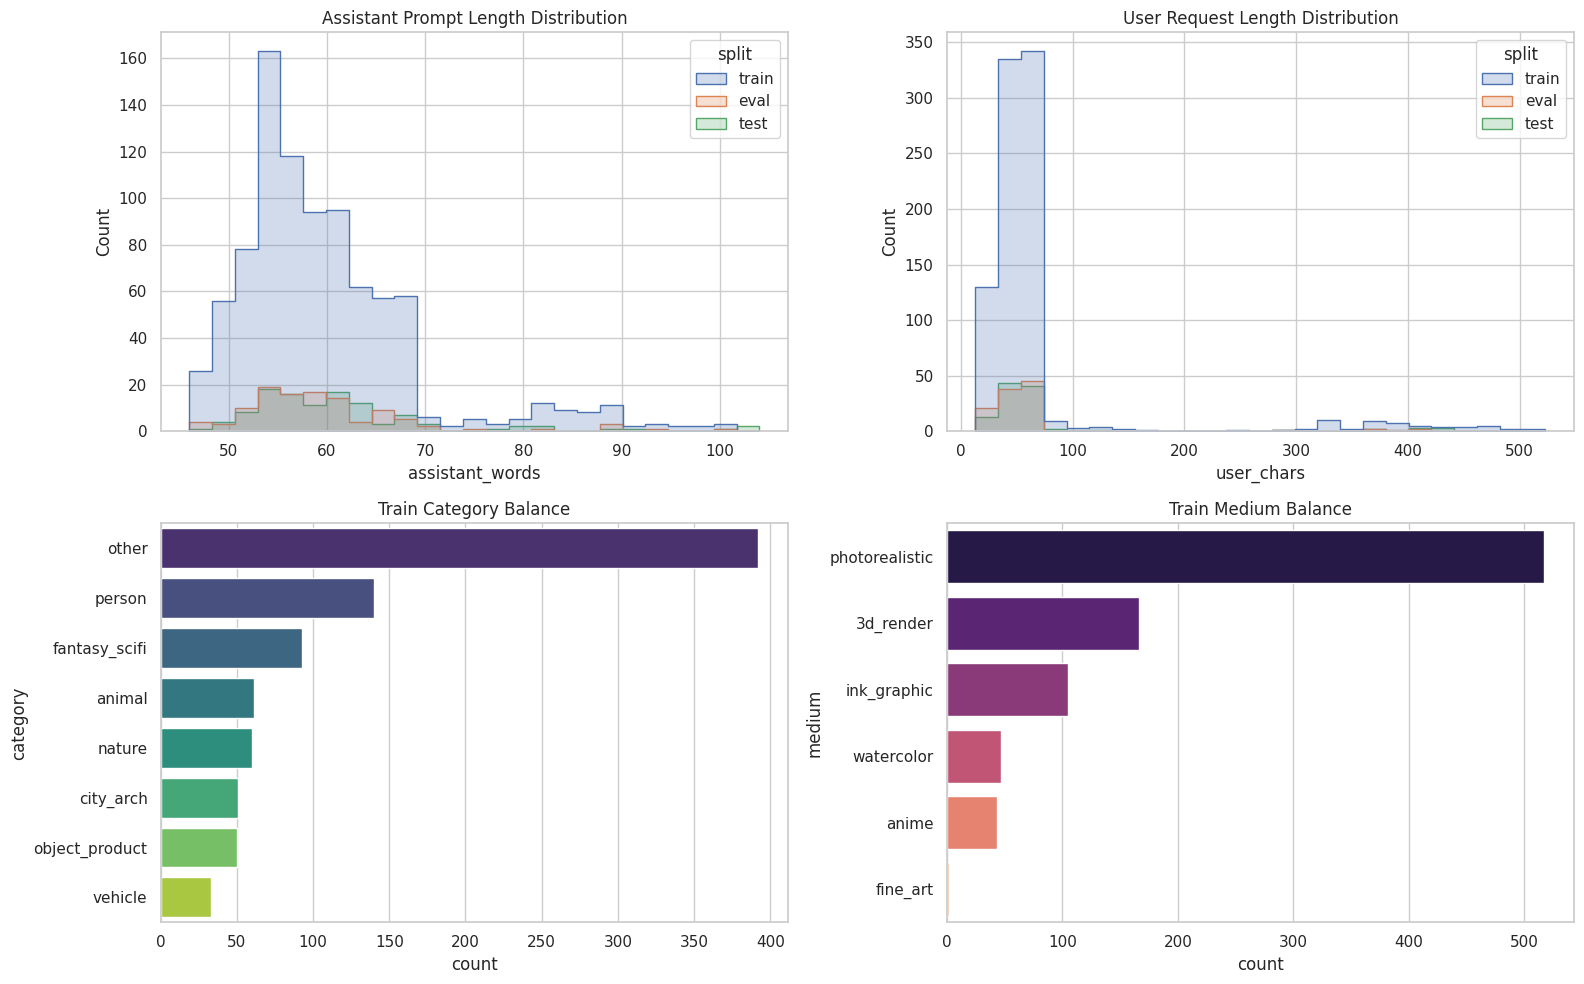

In [ ]:
# =========================
# 7. Визуализация датасета
# =========================

CATEGORY_KEYWORDS = {
    "animal": ["медвед", "волк", "тигр", "лев", "лиса", "кошка", "собак", "дракон", "кит", "сова", "cat", "dog", "tiger", "bear", "dragon"],
    "person": ["девуш", "женщин", "мужчин", "человек", "портрет", "подрост", "монах", "girl", "woman", "man", "portrait", "monk", "engineer"],
    "city_arch": ["город", "улица", "замок", "интерьер", "класс", "офис", "city", "street", "castle", "interior", "classroom", "office"],
    "nature": ["лес", "гора", "озеро", "река", "пустын", "океан", "лесу", "forest", "mountain", "lake", "river", "desert", "ocean"],
    "object_product": ["бутылк", "часы", "наушник", "шлем", "крем", "очки", "меч", "watch", "headphones", "helmet", "cream", "glasses"],
    "vehicle": ["автомобил", "машин", "мотоцикл", "корабл", "поезд", "марсоход", "car", "sedan", "ship", "train", "rover"],
    "fantasy_scifi": ["киберпанк", "футурист", "робот", "биомехан", "стимпанк", "cyberpunk", "futuristic", "robot", "biomechanical", "steampunk"],
}

def infer_category(text):
    text = text.lower()
    scores = {}
    for name, keywords in CATEGORY_KEYWORDS.items():
        scores[name] = sum(keyword in text for keyword in keywords)
    best_name, best_score = max(scores.items(), key=lambda item: item[1])
    return best_name if best_score > 0 else "other"

def infer_medium(text):
    text = text.lower()
    if "anime" in text or "аниме" in text:
        return "anime"
    if "3d" in text or "3д" in text or "render" in text:
        return "3d_render"
    if "oil painting" in text or "масля" in text:
        return "oil_painting"
    if "watercolor" in text or "акварель" in text:
        return "watercolor"
    if "ink" in text or "карандаш" in text or "тушью" in text:
        return "ink_graphic"
    if any(token in text for token in ["cubism", "сюрреал", "экспрессионизм", "импрессионизм", "поп-арт", "pop art"]):
        return "fine_art"
    return "photorealistic"

analysis_rows = []
for split_name, rows in [("train", train_rows), ("eval", eval_rows), ("test", test_rows)]:
    for row in rows:
        user_text = get_user_text(row)
        assistant_text = get_assistant_text(row)
        analysis_rows.append({
            "split": split_name,
            "user_chars": len(user_text),
            "assistant_words": len(assistant_text.split()),
            "category": infer_category(user_text),
            "medium": infer_medium(assistant_text),
        })

analysis_df = pd.DataFrame(analysis_rows)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(data=analysis_df, x="assistant_words", hue="split", bins=25, ax=axes[0, 0], element="step")
axes[0, 0].set_title("Assistant Prompt Length Distribution")

sns.histplot(data=analysis_df, x="user_chars", hue="split", bins=25, ax=axes[0, 1], element="step")
axes[0, 1].set_title("User Request Length Distribution")

category_counts = analysis_df[analysis_df["split"] == "train"]["category"].value_counts().reset_index()
category_counts.columns = ["category", "count"]
sns.barplot(data=category_counts, x="count", y="category", ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Train Category Balance")

medium_counts = analysis_df[analysis_df["split"] == "train"]["medium"].value_counts().reset_index()
medium_counts.columns = ["medium", "count"]
sns.barplot(data=medium_counts, x="count", y="medium", ax=axes[1, 1], palette="magma")
axes[1, 1].set_title("Train Medium Balance")

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 8. просмотр
# =========================

preview_df = pd.DataFrame(
    {
        "user": [get_user_text(row) for row in train_rows[:5]],
        "assistant": [get_assistant_text(row) for row in train_rows[:5]],
    }
)

display(preview_df)

,user,assistant
0,"Ноутбук закрывается с огромной силой, искры из...","A highly detailed modern laptop being slammed,..."
1,"Биомеханический сустав, вид под микроскопом, с...",Stylized artwork of microscopic view of nanobo...
2,"киберпанк хамелеон, неон, фото",Detailed ink illustration of chameleon with sh...
3,"Биомеханический глаз, вид изнутри на сетчатку ...",Stylized artwork of looking through a robotic ...
4,"Старушка на роликах несется по набережной, сти...",Detailed ink illustration of senior woman on s...


## Start Hyperparameters

Старт под `T4` для этого датасета:

- `NUM_EPOCHS = 3`
- `LEARNING_RATE = 6e-5`
- `BATCH_SIZE = 1`
- `GRAD_ACCUM = 8`
- `MAX_LEN = 1536`
- `LORA_R = 16`

Если модель начинает терять формат или переобучаться:

- снижай `NUM_EPOCHS` до `2`
- или снижай `LEARNING_RATE` до `5e-5`

In [ ]:
# =========================
# 9. гиперпараметры
# =========================

NUM_EPOCHS = 3
LEARNING_RATE = 6e-5
BATCH_SIZE = 1
GRAD_ACCUM = 8
MAX_LEN = 1536
LOG_STEPS = 10

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

GENERATION_MAX_NEW_TOKENS = 256

In [ ]:
# =========================
# 10. токенизация + assistant-only препроцессинг
# =========================

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def apply_template(messages, add_generation_prompt=False):
    kwargs = dict(tokenize=False, add_generation_prompt=add_generation_prompt)
    try:
        return tokenizer.apply_chat_template(messages, enable_thinking=False, **kwargs)
    except TypeError:
        return tokenizer.apply_chat_template(messages, **kwargs)

def preprocess(example):
    user_messages = [msg for msg in example["messages"] if msg["role"] == "user"]
    assistant_text = next(msg["content"] for msg in example["messages"] if msg["role"] == "assistant")

    prompt_text = apply_template(user_messages, add_generation_prompt=True)
    full_text = prompt_text + assistant_text + tokenizer.eos_token

    prompt_tokens = tokenizer(prompt_text, add_special_tokens=False)
    full_tokens = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LEN,
        padding=False,
        add_special_tokens=False,
    )

    labels = full_tokens["input_ids"].copy()
    prompt_len = min(len(prompt_tokens["input_ids"]), len(labels))
    labels[:prompt_len] = [-100] * prompt_len

    target_token_count = sum(label != -100 for label in labels)

    full_tokens["labels"] = labels
    full_tokens["prompt_length"] = prompt_len
    full_tokens["target_token_count"] = target_token_count
    full_tokens["total_length"] = len(full_tokens["input_ids"])
    return full_tokens

tokenized_train = raw_train_dataset.map(
    preprocess,
    remove_columns=raw_train_dataset.column_names,
    desc="Tokenizing train",
).filter(lambda row: row["target_token_count"] > 0)

tokenized_eval = raw_eval_dataset.map(
    preprocess,
    remove_columns=raw_eval_dataset.column_names,
    desc="Tokenizing eval",
).filter(lambda row: row["target_token_count"] > 0)

tokenized_test = raw_test_dataset.map(
    preprocess,
    remove_columns=raw_test_dataset.column_names,
    desc="Tokenizing test",
).filter(lambda row: row["target_token_count"] > 0)

print("Tokenized train:", len(tokenized_train))
print("Tokenized eval:", len(tokenized_eval))
print("Tokenized test:", len(tokenized_test))

Tokenizing eval:   0%|          | 0/110 [00:00<?, ? examples/s]

Filter:   0%|          | 0/110 [00:00<?, ? examples/s]

Tokenized train: 880
Tokenized eval: 110
Tokenized test: 110


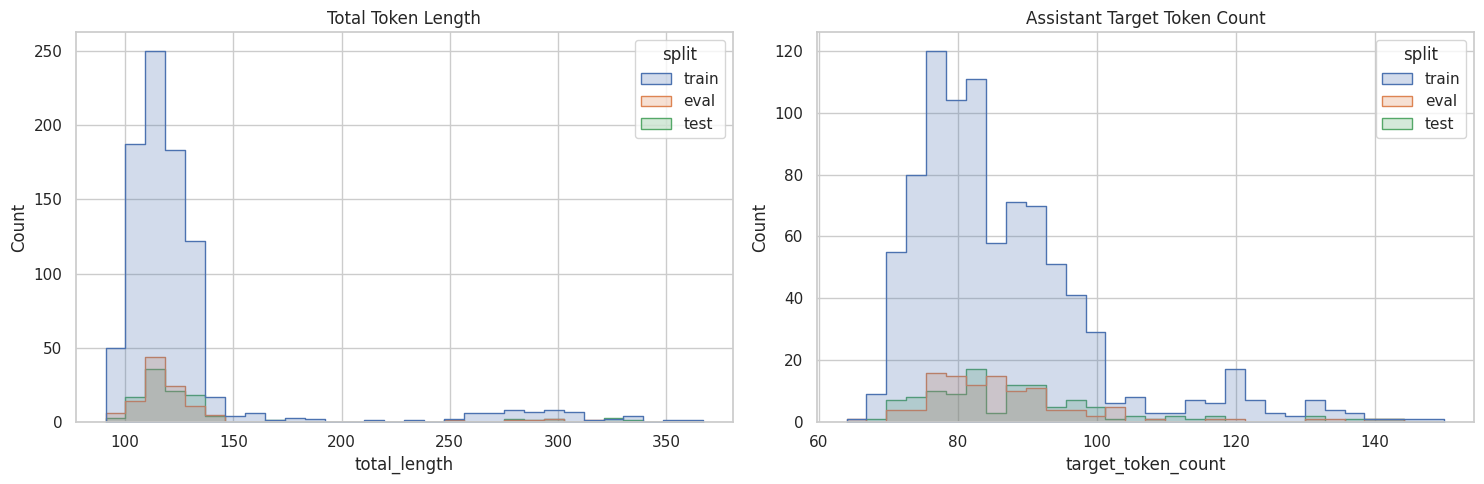

In [ ]:
# =========================
# 11. Визуализация длины токенов
# =========================

token_stats_df = pd.concat(
    [
        pd.DataFrame({"split": "train", "total_length": tokenized_train["total_length"], "target_token_count": tokenized_train["target_token_count"]}),
        pd.DataFrame({"split": "eval", "total_length": tokenized_eval["total_length"], "target_token_count": tokenized_eval["target_token_count"]}),
        pd.DataFrame({"split": "test", "total_length": tokenized_test["total_length"], "target_token_count": tokenized_test["target_token_count"]}),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=token_stats_df, x="total_length", hue="split", bins=30, element="step", ax=axes[0])
axes[0].set_title("Total Token Length")
sns.histplot(data=token_stats_df, x="target_token_count", hue="split", bins=30, element="step", ax=axes[1])
axes[1].set_title("Assistant Target Token Count")
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 12. настройка QLORA
# =========================

import math
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=train_dtype,
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    device_map="auto",
    quantization_config=bnb_config,
    torch_dtype=train_dtype,
)

model.config.use_cache = False
model = prepare_model_for_kbit_training(model)
model.gradient_checkpointing_enable()

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

train_steps = math.ceil(len(tokenized_train) / (BATCH_SIZE * GRAD_ACCUM)) * NUM_EPOCHS
print(f"Approx total train steps: {train_steps}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 17,432,576 || all params: 1,738,007,552 || trainable%: 1.0030
Approx total train steps: 330


In [ ]:
# =========================
# 13. TRAIN
# =========================

from transformers import (
    DataCollatorForSeq2Seq,
    Trainer,
    TrainingArguments,
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    logging_steps=LOG_STEPS,
    save_strategy="epoch",
    eval_strategy="epoch",
    save_total_limit=2,
    bf16=use_bf16,
    fp16=not use_bf16,
    optim="paged_adamw_8bit",
    max_grad_norm=1.0,
    report_to="none",
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    group_by_length=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    data_collator=data_collator,
)

train_result = trainer.train()
trainer.save_state()

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss
1,1.422200,1.517813
2,1.063300,1.183476
3,0.992500,1.137790


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
27,0.9976,3.762713,7.300645e-06,2.363636,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,0.9157,3.535041,5.449450e-06,2.454545,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,1.1538,4.970161,3.845375e-06,2.545455,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,0.9451,2.958447,2.504566e-06,2.636364,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,0.9173,4.279832,1.440519e-06,2.727273,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,1.1405,3.573735,6.639455e-07,2.818182,310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,0.8723,2.632318,1.826613e-07,2.909091,320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,0.9925,3.383824,1.511119e-09,3.000000,330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,NaN,NaN,NaN,3.000000,330,1.13779,18.8744,5.828,5.828,NaN,NaN,NaN,NaN,NaN
36,NaN,NaN,NaN,3.000000,330,NaN,NaN,NaN,NaN,1615.2255,1.634,0.204,2.968974e+15,1.60062


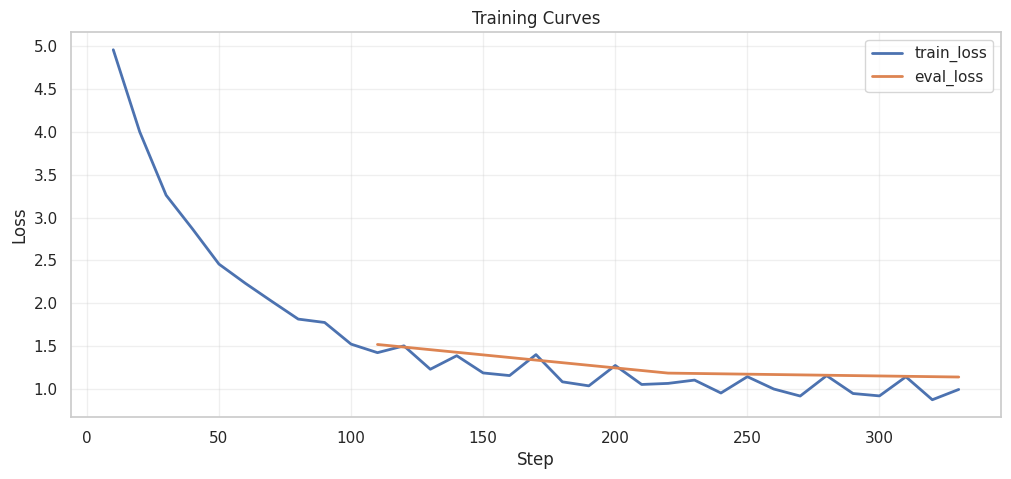

In [ ]:
# =========================
# 14. график обучения
# =========================

log_history = pd.DataFrame(trainer.state.log_history)
display(log_history.tail(10))

plt.figure(figsize=(12, 5))
if "loss" in log_history:
    train_log = log_history.dropna(subset=["loss"])
    plt.plot(train_log["step"], train_log["loss"], label="train_loss", linewidth=2)
if "eval_loss" in log_history:
    eval_log = log_history.dropna(subset=["eval_loss"])
    plt.plot(eval_log["step"], eval_log["eval_loss"], label="eval_loss", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# =========================
# 15. Сохранение адаптера
# =========================

trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Saved adapter to:", OUTPUT_DIR)

Saved adapter to: /content/qwen3_1_7b_sdxl_prompt_lora


In [ ]:
# =========================
# 16. INFERENCE
# =========================

from peft import PeftModel

def cleanup_model(*objs):
    for obj in objs:
        if obj is not None:
            del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

cleanup_model(model)

def load_base_model_for_eval():
    tok = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_PATH,
        device_map="auto",
        torch_dtype=train_dtype,
    )
    mdl.eval()
    return tok, mdl

def load_finetuned_model_for_eval():
    tok = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_PATH,
        device_map="auto",
        torch_dtype=train_dtype,
    )
    mdl = PeftModel.from_pretrained(base, OUTPUT_DIR)
    mdl.eval()
    return tok, mdl

In [ ]:
# =========================
# 17. настройки генерации
# =========================

def build_eval_text(tokenizer_obj, user_text):
    messages = [{"role": "user", "content": user_text}]
    kwargs = dict(tokenize=False, add_generation_prompt=True)
    try:
        return tokenizer_obj.apply_chat_template(messages, enable_thinking=False, **kwargs)
    except TypeError:
        return tokenizer_obj.apply_chat_template(messages, **kwargs)

def clean_text(text):
    text = text.replace("<think>", "").replace("</think>", "").strip()
    return " ".join(text.split())

def generate_one(model_obj, tokenizer_obj, user_text, max_new_tokens=GENERATION_MAX_NEW_TOKENS, do_sample=False):
    text = build_eval_text(tokenizer_obj, user_text)
    inputs = tokenizer_obj(text, return_tensors="pt").to(model_obj.device)

    generation_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        repetition_penalty=1.05,
        pad_token_id=tokenizer_obj.eos_token_id,
    )
    if do_sample:
        generation_kwargs["temperature"] = 0.7
        generation_kwargs["top_p"] = 0.95

    with torch.inference_mode():
        outputs = model_obj.generate(**inputs, **generation_kwargs)

    generated = outputs[0][inputs["input_ids"].shape[-1]:]
    return clean_text(tokenizer_obj.decode(generated, skip_special_tokens=True))

In [ ]:
# =========================
# 18. "ручной" бенчмарк
# =========================

benchmark_prompts = [
    "бурый медведь в лесу",
    "девушка в красном пальто под дождем ночью",
    "киберпанк город с неоном и летающими машинами",
]

    # "старый замок на скале в тумане",
    # "белый волк на снегу при лунном свете",
    # "аниме девушка в пустом классе 90-х",
    # "золотые наручные часы на черном фоне, макро",
    # "космический корабль над ледяной планетой",
    # "кофе во френч-прессе крупным планом",
    # "монах на вершине горы в грозу",
    # "лиса прыгает через ручей в осеннем лесу",
    # "футуристический шлем, 3д рендер",

benchmark_records = []
base_tok, base_model = load_base_model_for_eval()
for prompt in benchmark_prompts:
    benchmark_records.append(
        {
            "user": prompt,
            "base_prediction": generate_one(base_model, base_tok, prompt),
        }
    )
cleanup_model(base_model)

ft_tok, ft_model = load_finetuned_model_for_eval()
for record in benchmark_records:
    record["finetuned_prediction"] = generate_one(ft_model, ft_tok, record["user"])
cleanup_model(ft_model)

benchmark_df = pd.DataFrame(benchmark_records)
benchmark_df.to_csv(ARTIFACTS_DIR / "manual_benchmark.csv", index=False)
display(benchmark_df)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

,user,base_prediction,finetuned_prediction
0,бурый медведь в лесу,"Бурый медведь — это крупный, сильный и хищный ...",A highly detailed polar bear standing on a fro...
1,девушка в красном пальто под дождем ночью,Эта образная и эмоциональная фраза передает ат...,A highly detailed night scene of a woman in a ...
2,киберпанк город с неоном и летающими машинами,"Киберпанк — это жанр, который сочетает элемент...",A highly detailed futuristic cityscape at nigh...


In [ ]:
# =========================
# чат с адаптером
# =========================

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch
import gc

def cleanup_model(*objs):
    for obj in objs:
        if obj is not None:
            del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def clean_text(text):
    text = text.replace("<think>", "").replace("</think>", "").strip()
    return " ".join(text.split())

def build_eval_text(tokenizer_obj, user_text):
    messages = [{"role": "user", "content": user_text}]
    kwargs = dict(tokenize=False, add_generation_prompt=True)
    try:
        return tokenizer_obj.apply_chat_template(messages, enable_thinking=False, **kwargs)
    except TypeError:
        return tokenizer_obj.apply_chat_template(messages, **kwargs)

CHECKPOINT_PATH = "/content/qwen3_1_7b_sdxl_prompt_lora/checkpoint-220"
# CHECKPOINT_PATH = str(OUTPUT_DIR)
# пример:
# CHECKPOINT_PATH = "/content/qwen3_1_7b_sdxl_prompt_lora/checkpoint-220"

cleanup_model()

chat_tok = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
if chat_tok.pad_token is None:
    chat_tok.pad_token = chat_tok.eos_token

chat_base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    device_map="auto",
    torch_dtype=train_dtype,
)

chat_model = PeftModel.from_pretrained(chat_base, CHECKPOINT_PATH)
chat_model.eval()

def chat_once(user_text, max_new_tokens=256, do_sample=False, temperature=0.7, top_p=0.95):
    text = build_eval_text(chat_tok, user_text)
    inputs = chat_tok(text, return_tensors="pt").to(chat_model.device)

    generation_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        repetition_penalty=1.05,
        pad_token_id=chat_tok.eos_token_id,
    )
    if do_sample:
        generation_kwargs["temperature"] = temperature
        generation_kwargs["top_p"] = top_p

    with torch.inference_mode():
        outputs = chat_model.generate(**inputs, **generation_kwargs)

    generated = outputs[0][inputs["input_ids"].shape[-1]:]
    return clean_text(chat_tok.decode(generated, skip_special_tokens=True))

while True:
    user_text = input("User: ").strip()
    if user_text.lower() in {"exit", "quit", "q"}:
        print("Chat stopped.")
        break
    if not user_text:
        continue

    answer = chat_once(user_text, max_new_tokens=256, do_sample=False)
    print("Model:", answer)
    print()


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model: Detailed thought process for creating a cyberpunk anime character, high contrast lighting, neon reflections on glass, glowing digital patterns, sharp angular shapes of the city, vibrant teal and blue color palette, dynamic pose, strong emotional read, clear focal character, detailed silhouette, strong worldbuilding, immersive atmosphere, cinematic scale, high detail, professional anime illustration, precise line work, clean line art, rich surface texture, polished anime finish

Model: Creative writing prompt: A scream of a woman, sharp and high-pitched, echoing through the empty hallways of a hospital. The sound is not just a sound, but a physical presence, vibrating in the air like a trapped breath. The atmosphere is tense, with faint echoes of previous screams, and the silence between them is thick. The light is dim, casting long shadows on the walls, and the floorboards creak underfoot. A single red rose lies on the floor, petals scattered like shattered glass. The scent of a

KeyboardInterrupt: Interrupted by user

In [ ]:
from pathlib import Path
import shutil
import os

TARGET_DIR = Path("/content/qwen3_1_7b_sdxl_prompt_lora/checkpoint-220")
# TARGET_DIR = Path("/content/qwen3_1_7b_sdxl_prompt_lora")

assert TARGET_DIR.exists(), f"Не найдена папка: {TARGET_DIR}"

zip_basename = Path("/content") / TARGET_DIR.name
archive_path = shutil.make_archive(
    base_name=str(zip_basename),
    format="zip",
    root_dir=str(TARGET_DIR.parent),
    base_dir=TARGET_DIR.name,
)

size_mb = os.path.getsize(archive_path) / 1024 / 1024
print(f"Saved: {archive_path}")
print(f"Size: {size_mb:.2f} MB")


Saved: /content/checkpoint-220.zip
Size: 95.71 MB


In [ ]:
# =========================
# STAGE-2
# =========================
import gc
import json
import math
from pathlib import Path

import torch
from datasets import load_dataset
from peft import PeftModel, prepare_model_for_kbit_training
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    Trainer,
    TrainingArguments,
)


BASE_MODEL_PATH = "/content/qwen3_1_7b"
CHECKPOINT_PATH = "/content/qwen3_1_7b_sdxl_prompt_lora/checkpoint-220"
# CHECKPOINT_PATH = "/content/qwen3_1_7b_sdxl_prompt_lora/checkpoint-330"

STAGE2_TRAIN_JSONL = "/content/data/sdxl_stage2_corrective_208_train.jsonl"
STAGE2_EVAL_JSONL = "/content/data/sdxl_stage2_corrective_208_eval.jsonl"
STAGE2_TEST_JSONL = "/content/data/sdxl_stage2_corrective_208_test.jsonl"
STAGE2_OUTPUT_DIR = "/content/qwen3_1_7b_sdxl_prompt_lora_stage2_from_ckpt220"

NUM_EPOCHS = 1
LEARNING_RATE = 1e-5
BATCH_SIZE = 1
GRAD_ACCUM = 8
MAX_LEN = 1024
LOG_STEPS = 5

LORA_DROPOUT = 0.05
GENERATION_MAX_NEW_TOKENS = 256

use_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
train_dtype = torch.bfloat16 if use_bf16 else torch.float16

SYSTEM_PROMPT = (
    "You are an SDXL prompt writer. Preserve all entities, species, colors, counts, "
    "clothing, materials, and environments from the user request exactly. "
    "Do not replace or invent key subjects. Output one English SDXL prompt only."
)


def cleanup_model(*objs):
    for obj in objs:
        if obj is not None:
            del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


raw_train_dataset = load_dataset("json", data_files=STAGE2_TRAIN_JSONL, split="train")
raw_eval_dataset = load_dataset("json", data_files=STAGE2_EVAL_JSONL, split="train")
raw_test_dataset = load_dataset("json", data_files=STAGE2_TEST_JSONL, split="train")

print("Stage-2 train:", len(raw_train_dataset))
print("Stage-2 eval:", len(raw_eval_dataset))
print("Stage-2 test:", len(raw_test_dataset))


def apply_stage2_template(user_text, add_generation_prompt=False):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_text},
    ]
    kwargs = dict(tokenize=False, add_generation_prompt=add_generation_prompt)
    try:
        return tokenizer.apply_chat_template(messages, enable_thinking=False, **kwargs)
    except TypeError:
        return tokenizer.apply_chat_template(messages, **kwargs)


def preprocess_stage2(example):
    user_text = next(msg["content"] for msg in example["messages"] if msg["role"] == "user")
    assistant_text = next(msg["content"] for msg in example["messages"] if msg["role"] == "assistant")

    prompt_text = apply_stage2_template(user_text, add_generation_prompt=True)
    full_text = prompt_text + assistant_text + tokenizer.eos_token

    prompt_tokens = tokenizer(prompt_text, add_special_tokens=False)
    full_tokens = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LEN,
        padding=False,
        add_special_tokens=False,
    )

    labels = full_tokens["input_ids"].copy()
    prompt_len = min(len(prompt_tokens["input_ids"]), len(labels))
    labels[:prompt_len] = [-100] * prompt_len

    full_tokens["labels"] = labels
    full_tokens["target_token_count"] = sum(label != -100 for label in labels)
    full_tokens["total_length"] = len(full_tokens["input_ids"])
    return full_tokens


tokenized_train = raw_train_dataset.map(
    preprocess_stage2,
    remove_columns=raw_train_dataset.column_names,
    desc="Tokenizing stage-2 train",
).filter(lambda row: row["target_token_count"] > 0)

tokenized_eval = raw_eval_dataset.map(
    preprocess_stage2,
    remove_columns=raw_eval_dataset.column_names,
    desc="Tokenizing stage-2 eval",
).filter(lambda row: row["target_token_count"] > 0)

print("Tokenized stage-2 train:", len(tokenized_train))
print("Tokenized stage-2 eval:", len(tokenized_eval))


bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=train_dtype,
)

cleanup_model()

base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    device_map="auto",
    quantization_config=bnb_config,
    torch_dtype=train_dtype,
)

base.config.use_cache = False
base = prepare_model_for_kbit_training(base)
base.gradient_checkpointing_enable()

model = PeftModel.from_pretrained(base, CHECKPOINT_PATH, is_trainable=True)
model.print_trainable_parameters()

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

steps_per_epoch = math.ceil(len(tokenized_train) / (BATCH_SIZE * GRAD_ACCUM))
SAVE_EVAL_STEPS = max(5, steps_per_epoch // 2)

print("Stage-2 steps per epoch:", steps_per_epoch)
print("Stage-2 save/eval every steps:", SAVE_EVAL_STEPS)

training_args = TrainingArguments(
    output_dir=STAGE2_OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=LOG_STEPS,
    save_strategy="steps",
    eval_strategy="steps",
    save_steps=SAVE_EVAL_STEPS,
    eval_steps=SAVE_EVAL_STEPS,
    save_total_limit=3,
    bf16=use_bf16,
    fp16=not use_bf16,
    optim="paged_adamw_8bit",
    max_grad_norm=1.0,
    report_to="none",
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    group_by_length=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    data_collator=data_collator,
)

train_result = trainer.train()
trainer.save_state()
trainer.model.save_pretrained(STAGE2_OUTPUT_DIR)
tokenizer.save_pretrained(STAGE2_OUTPUT_DIR)

print("Stage-2 adapter saved to:", STAGE2_OUTPUT_DIR)


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Stage-2 train: 168
Stage-2 eval: 20
Stage-2 test: 20


Tokenizing stage-2 train:   0%|          | 0/168 [00:00<?, ? examples/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


trainable params: 17,432,576 || all params: 1,738,007,552 || trainable%: 1.0030
Stage-2 steps per epoch: 21
Stage-2 save/eval every steps: 10


Step,Training Loss,Validation Loss
10,2.063100,1.882650
20,1.881500,1.787795


Stage-2 adapter saved to: /content/qwen3_1_7b_sdxl_prompt_lora_stage2_from_ckpt220


In [ ]:
# =========================
# чат с STAGE-2
# =========================

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch
import gc

BASE_MODEL_PATH = "/content/qwen3_1_7b"
ADAPTER_PATH = "/content/qwen3_1_7b_sdxl_prompt_lora_stage2_from_ckpt220"


SYSTEM_PROMPT = (
    "You are an SDXL prompt writer. Preserve all entities, species, colors, counts, "
    "clothing, materials, and environments from the user request exactly. "
    "Do not replace or invent key subjects. Output one English SDXL prompt only."
)

train_dtype = torch.float16

def cleanup_model(*objs):
    for obj in objs:
        if obj is not None:
            del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def clean_text(text):
    text = text.replace("<think>", "").replace("</think>", "").strip()
    return " ".join(text.split())

def build_chat_text(tokenizer_obj, user_text):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_text},
    ]
    kwargs = dict(tokenize=False, add_generation_prompt=True)
    try:
        return tokenizer_obj.apply_chat_template(messages, enable_thinking=False, **kwargs)
    except TypeError:
        return tokenizer_obj.apply_chat_template(messages, **kwargs)

cleanup_model()

chat_tok = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
if chat_tok.pad_token is None:
    chat_tok.pad_token = chat_tok.eos_token

chat_base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    device_map="auto",
    torch_dtype=train_dtype,
)

chat_model = PeftModel.from_pretrained(chat_base, ADAPTER_PATH)
chat_model.eval()

def chat_once(user_text, max_new_tokens=500, do_sample=False, temperature=0.8, top_p=0.95):
    text = build_chat_text(chat_tok, user_text)
    inputs = chat_tok(text, return_tensors="pt").to(chat_model.device)

    generation_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        repetition_penalty=1.05,
        pad_token_id=chat_tok.eos_token_id,
    )
    if do_sample:
        generation_kwargs["temperature"] = temperature
        generation_kwargs["top_p"] = top_p

    with torch.inference_mode():
        outputs = chat_model.generate(**inputs, **generation_kwargs)

    generated = outputs[0][inputs["input_ids"].shape[-1]:]
    return clean_text(chat_tok.decode(generated, skip_special_tokens=True))

while True:
    user_text = input("User: ").strip()
    if user_text.lower() in {"exit", "quit", "q"}:
        print("Chat stopped.")
        break
    if not user_text:
        continue

    answer = chat_once(user_text, max_new_tokens=500, do_sample=False)
    print("Model:", answer)
    print()


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

User: бурый медведь в лесу
Model: A large brown bear standing in a forest clearing, strong legs, thick fur, sharp teeth, muddy paws, tall grass, dense foliage, clear silhouette, natural lighting, realistic textures, high detail, clean visual storytelling, precise environmental detail, immersive atmosphere, rich environmental detail, photorealistic, ultra-detailed, 8k, ultra realistic



KeyboardInterrupt: Interrupted by user

In [ ]:
from pathlib import Path
import shutil
import os

TARGET_DIR = Path("/content/qwen3_1_7b_sdxl_prompt_lora_stage2_from_ckpt220")

assert TARGET_DIR.exists(), f"Не найдена папка: {TARGET_DIR}"

zip_basename = Path("/content") / TARGET_DIR.name
archive_path = shutil.make_archive(
    base_name=str(zip_basename),
    format="zip",
    root_dir=str(TARGET_DIR.parent),
    base_dir=TARGET_DIR.name,
)

size_mb = os.path.getsize(archive_path) / 1024 / 1024
print(f"Saved: {archive_path}")
print(f"Size: {size_mb:.2f} MB")


Saved: /content/qwen3_1_7b_sdxl_prompt_lora_stage2_from_ckpt220.zip
Size: 353.01 MB


In [ ]:
# =========================
# сравнение STAGE-1 VS STAGE-2
# =========================

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import pandas as pd
import torch
import gc

BASE_MODEL_PATH = "/content/qwen3_1_7b"

OLD_ADAPTER_PATH = "/content/qwen3_1_7b_sdxl_prompt_lora/checkpoint-220"
STAGE2_ADAPTER_PATH = "/content/qwen3_1_7b_sdxl_prompt_lora_stage2_from_ckpt220"

SYSTEM_PROMPT = (
    "You are an SDXL prompt writer. Preserve all entities, species, colors, counts, "
    "clothing, materials, and environments from the user request exactly. "
    "Do not replace or invent key subjects. Output one English SDXL prompt only."
)

TEST_PROMPTS = [
    "бурый медведь в лесу",
    "белый волк на снегу",
    "девушка в киберпанк городе стоит на балконе в красном неоновом платье",
    "черный ворон сидит на ветке в туманном лесу",
    "красный автомобиль в пустыне",
]

train_dtype = torch.float16

def cleanup_model(*objs):
    for obj in objs:
        if obj is not None:
            del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def clean_text(text):
    text = text.replace("<think>", "").replace("</think>", "").strip()
    return " ".join(text.split())

def build_chat_text(tokenizer_obj, user_text):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_text},
    ]
    kwargs = dict(tokenize=False, add_generation_prompt=True)
    try:
        return tokenizer_obj.apply_chat_template(messages, enable_thinking=False, **kwargs)
    except TypeError:
        return tokenizer_obj.apply_chat_template(messages, **kwargs)

def load_adapter(adapter_path):
    tok = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_PATH,
        device_map="auto",
        torch_dtype=train_dtype,
    )
    model = PeftModel.from_pretrained(base, adapter_path)
    model.eval()
    return tok, model

def generate_one(model_obj, tokenizer_obj, user_text, max_new_tokens=220):
    text = build_chat_text(tokenizer_obj, user_text)
    inputs = tokenizer_obj(text, return_tensors="pt").to(model_obj.device)

    with torch.inference_mode():
        outputs = model_obj.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.05,
            pad_token_id=tokenizer_obj.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[-1]:]
    return clean_text(tokenizer_obj.decode(generated, skip_special_tokens=True))

records = []

old_tok, old_model = load_adapter(OLD_ADAPTER_PATH)
for prompt in TEST_PROMPTS:
    records.append({
        "user": prompt,
        "old_adapter": generate_one(old_model, old_tok, prompt),
    })
cleanup_model(old_model)

stage2_tok, stage2_model = load_adapter(STAGE2_ADAPTER_PATH)
for row in records:
    row["stage2_adapter"] = generate_one(stage2_model, stage2_tok, row["user"])
cleanup_model(stage2_model)

compare_df = pd.DataFrame(records)
display(compare_df)

compare_df.to_csv("/content/adapter_comparison_5_prompts.csv", index=False)
print("Saved to: /content/adapter_comparison_5_prompts.csv")


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

,user,old_adapter,stage2_adapter
0,бурый медведь в лесу,A large polar bear standing in a forest cleari...,A large brown bear standing in a forest cleari...
1,белый волк на снегу,A white wolf standing on a snowy mountain peak...,"A white wolf on a snowy mountain peak, snow-co..."
2,девушка в киберпанк городе стоит на балконе в ...,A young woman in a red neon dress stands on a ...,A young woman in a red neon dress stands on a ...
3,черный ворон сидит на ветке в туманном лесу,A black kestrel perched on a tree branch in a ...,A black crow perched on a tree branch in a mis...
4,красный автомобиль в пустыне,"A red car in a desert, 80% of the frame is san...","A red car in a desert, 80% of the frame is san..."


Saved to: /content/adapter_comparison_5_prompts.csv


In [ ]:
# =========================
# 19. Метрики
# =========================

rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("sacrebleu")
bertscore_metric = evaluate.load("bertscore")

def split_tags(text):
    return [tag.strip().lower() for tag in text.split(",") if tag.strip()]

def tag_jaccard(preds, refs):
    scores = []
    for pred, ref in zip(preds, refs):
        pred_set = set(split_tags(pred))
        ref_set = set(split_tags(ref))
        union = pred_set | ref_set
        scores.append(len(pred_set & ref_set) / len(union) if union else 1.0)
    return float(np.mean(scores))

def exact_match_score(preds, refs):
    norm_preds = [clean_text(x).lower() for x in preds]
    norm_refs = [clean_text(x).lower() for x in refs]
    return float(np.mean([p == r for p, r in zip(norm_preds, norm_refs)]))

def english_only_rate(texts):
    return float(np.mean([not has_cyrillic(text) for text in texts]))

def think_leak_rate(texts):
    return float(np.mean(["<think>" in text.lower() or "</think>" in text.lower() for text in texts]))

def avg_word_count(texts):
    return float(np.mean([len(text.split()) for text in texts]))

def length_ratio(preds, refs):
    ratios = []
    for pred, ref in zip(preds, refs):
        ref_len = max(len(ref.split()), 1)
        ratios.append(len(pred.split()) / ref_len)
    return float(np.mean(ratios))

def compute_metrics(preds, refs):
    rouge_scores = rouge_metric.compute(predictions=preds, references=refs)
    bleu_score = bleu_metric.compute(predictions=preds, references=[[x] for x in refs])["score"] / 100.0
    bert = bertscore_metric.compute(predictions=preds, references=refs, lang="en")

    return {
        "bleu": float(bleu_score),
        "rouge1": float(rouge_scores["rouge1"]),
        "rouge2": float(rouge_scores["rouge2"]),
        "rougeL": float(rouge_scores["rougeL"]),
        "bertscore_f1": float(np.mean(bert["f1"])),
        "tag_jaccard": tag_jaccard(preds, refs),
        "exact_match": exact_match_score(preds, refs),
        "english_only_rate": english_only_rate(preds),
        "think_leak_rate": think_leak_rate(preds),
        "avg_words": avg_word_count(preds),
        "length_ratio_vs_ref": length_ratio(preds, refs),
    }

def run_generation_benchmark(dataset_obj, tokenizer_obj, model_obj, model_name, save_path):
    records = []
    preds = []
    refs = []

    for row in dataset_obj:
        user_text = get_user_text(row)
        ref_text = clean_text(get_assistant_text(row))
        pred_text = generate_one(model_obj, tokenizer_obj, user_text)

        preds.append(pred_text)
        refs.append(ref_text)
        records.append(
            {
                "model": model_name,
                "user": user_text,
                "reference": ref_text,
                "prediction": pred_text,
            }
        )

    df = pd.DataFrame(records)
    df.to_csv(save_path, index=False)
    metrics = compute_metrics(preds, refs)
    return df, metrics

def save_metrics(metrics_dict, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(metrics_dict, f, ensure_ascii=False, indent=2)

def plot_metric_comparison(base_metrics, finetuned_metrics, title):
    metric_names = list(base_metrics.keys())
    base_values = [base_metrics[name] for name in metric_names]
    finetuned_values = [finetuned_metrics[name] for name in metric_names]

    x = np.arange(len(metric_names))
    width = 0.38

    plt.figure(figsize=(14, 6))
    bars_a = plt.bar(x - width / 2, base_values, width, label="Base Qwen3-1.7B")
    bars_b = plt.bar(x + width / 2, finetuned_values, width, label="Qwen3-1.7B + LoRA")
    plt.xticks(x, metric_names, rotation=25)
    plt.ylabel("Score")
    plt.title(title)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.legend()

    for bars in (bars_a, bars_b):
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    plt.tight_layout()
    plt.show()

In [ ]:
# =========================
# 24. очистка
# =========================

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Artifacts saved to:", ARTIFACTS_DIR)

Artifacts saved to: /content/artifacts


## Final Eval Comparison

Финальный блок для сравнения:

- распаковка сохранённых `stage 1` и `stage 2` адаптеров из архивов
- сравнение `base vs stage 1 vs stage 2` на `eval`-наборе
- расчёт автоматических метрик качества
- построение двух итоговых графиков

In [1]:
# =========================
# 25. подготовка адаптеров
# =========================

from pathlib import Path
import zipfile

ARCHIVE_DIR_CANDIDATES = [Path("/content"), Path("/content/data")]

STAGE1_ZIP_CANDIDATES = [
    "checkpoint-220.zip",
]

STAGE2_ZIP_CANDIDATES = [
    "qwen3_1_7b_sdxl_prompt_lora_stage2_from_ckpt220.zip",
]

STAGE1_ADAPTER_PATH = Path("/content/checkpoint-220")
STAGE2_ADAPTER_PATH = Path("/content/qwen3_1_7b_sdxl_prompt_lora_stage2_from_ckpt220")

def find_archive(names):
    for base_dir in ARCHIVE_DIR_CANDIDATES:
        for name in names:
            candidate = base_dir / name
            if candidate.exists():
                return candidate
    return None

def ensure_unpacked(archive_path, expected_dir):
    expected_dir = Path(expected_dir)
    if expected_dir.exists() and any(expected_dir.iterdir()):
        print(f"Already unpacked: {expected_dir}")
        return expected_dir

    assert archive_path is not None, f"Archive not found for: {expected_dir.name}"
    assert archive_path.exists(), f"Archive file does not exist: {archive_path}"

    print(f"Unpacking {archive_path} -> {expected_dir.parent}")
    with zipfile.ZipFile(archive_path, "r") as zf:
        zf.extractall(expected_dir.parent)

    assert expected_dir.exists(), f"Expected extracted directory not found: {expected_dir}"
    return expected_dir

stage1_zip_path = find_archive(STAGE1_ZIP_CANDIDATES)
stage2_zip_path = find_archive(STAGE2_ZIP_CANDIDATES)

ensure_unpacked(stage1_zip_path, STAGE1_ADAPTER_PATH)
ensure_unpacked(stage2_zip_path, STAGE2_ADAPTER_PATH)

print("Stage 1 adapter dir:", STAGE1_ADAPTER_PATH)
print("Stage 2 adapter dir:", STAGE2_ADAPTER_PATH)

Already unpacked: /content/checkpoint-220
Already unpacked: /content/qwen3_1_7b_sdxl_prompt_lora_stage2_from_ckpt220
Stage 1 adapter dir: /content/checkpoint-220
Stage 2 adapter dir: /content/qwen3_1_7b_sdxl_prompt_lora_stage2_from_ckpt220


In [5]:
!pip install rouge_score \
 sacrebleu \
 bert_score \



In [1]:
!pip uninstall -y torchvision torchaudio
!pip install -q --no-cache-dir --force-reinstall \
  torchvision==0.25.0 \
  torchaudio==2.10.0 \
  --index-url https://download.pytorch.org/whl/cu130

Found existing installation: torchvision 0.25.0+cu130
Uninstalling torchvision-0.25.0+cu130:
  Successfully uninstalled torchvision-0.25.0+cu130
Found existing installation: torchaudio 2.10.0+cu130
Uninstalling torchaudio-2.10.0+cu130:
  Successfully uninstalled torchaudio-2.10.0+cu130
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 129.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 91.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 64.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.3/351.3 MB 120.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 222.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 213.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 84.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 243.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 190.8 MB/

In [ ]:
import os
os.kill(os.getpid(), 9)


In [2]:
import torch, torchvision, torchaudio
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("torchaudio:", torchaudio.__version__)
print(torch.version.cuda)

torch: 2.10.0+cu130
torchvision: 0.25.0+cu130
torchaudio: 2.10.0+cu130
13.0


In [9]:
!pip install -q torchvision==0.25.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 782.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 120.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires cuda-toolkit[cublas,cufft,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.
cudf-cu12 26.2.1 requires cuda-toolkit[nvcc,nvrtc]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.


In [12]:
!pip uninstall -y jax jaxlib


Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2


In [3]:
!pip uninstall -y bitsandbytes


Found existing installation: bitsandbytes 0.49.2
Uninstalling bitsandbytes-0.49.2:
  Successfully uninstalled bitsandbytes-0.49.2


In [4]:
# =========================
# 26. EVAL: BASE VS STAGE1 VS STAGE2(старый евал датасет)
# =========================

import gc
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from bert_score import score as bertscore_score
from peft import PeftModel
from rouge_score import rouge_scorer
from sacrebleu import corpus_bleu
from transformers import AutoModelForCausalLM, AutoTokenizer

BASE_MODEL_PATH = "/content/qwen3_1_7b"
FINAL_EVAL_JSONL = Path("/content/data/sdxl_stage2_corrective_208_eval.jsonl")

ARTIFACTS_DIR = Path("/content/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_REPORT_DIR = ARTIFACTS_DIR / "final_model_comparison"
FINAL_REPORT_DIR.mkdir(parents=True, exist_ok=True)

STAGE1_ADAPTER_PATH = Path("/content/checkpoint-220")
STAGE2_ADAPTER_PATH = Path("/content/qwen3_1_7b_sdxl_prompt_lora_stage2_from_ckpt220")

use_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
train_dtype = torch.bfloat16 if use_bf16 else torch.float16

USE_STAGE2_SYSTEM_PROMPT = True
STAGE2_SYSTEM_PROMPT = (
    "You are an SDXL prompt writer. Preserve all entities, species, colors, counts, "
    "clothing, materials, and environments from the user request exactly. "
    "Do not replace or invent key subjects. Output one English SDXL prompt only."
)

rouge_eval = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def cleanup_eval_models(*objs):
    for obj in objs:
        if obj is not None:
            del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def clean_eval_text(text):
    text = text.replace("<think>", "").replace("</think>", "").strip()
    return " ".join(text.split())

def has_cyrillic_eval(text):
    return bool(re.search(r"[А-Яа-яЁё]", text))

def split_tags_eval(text):
    return [tag.strip().lower() for tag in text.split(",") if tag.strip()]

def tag_jaccard_eval(preds, refs):
    scores = []
    for pred, ref in zip(preds, refs):
        pred_set = set(split_tags_eval(pred))
        ref_set = set(split_tags_eval(ref))
        union = pred_set | ref_set
        scores.append(len(pred_set & ref_set) / len(union) if union else 1.0)
    return float(np.mean(scores))

def exact_match_eval(preds, refs):
    norm_preds = [clean_eval_text(x).lower() for x in preds]
    norm_refs = [clean_eval_text(x).lower() for x in refs]
    return float(np.mean([p == r for p, r in zip(norm_preds, norm_refs)]))

def english_only_rate_eval(texts):
    return float(np.mean([not has_cyrillic_eval(text) for text in texts]))

def think_leak_rate_eval(texts):
    return float(np.mean(["<think>" in text.lower() or "</think>" in text.lower() for text in texts]))

def avg_word_count_eval(texts):
    return float(np.mean([len(text.split()) for text in texts]))

def length_ratio_eval(preds, refs):
    ratios = []
    for pred, ref in zip(preds, refs):
        ref_len = max(len(ref.split()), 1)
        ratios.append(len(pred.split()) / ref_len)
    return float(np.mean(ratios))

def compute_eval_metrics(preds, refs):
    rouge_1_scores = []
    rouge_2_scores = []
    rouge_l_scores = []
    for pred, ref in zip(preds, refs):
        score = rouge_eval.score(ref, pred)
        rouge_1_scores.append(score["rouge1"].fmeasure)
        rouge_2_scores.append(score["rouge2"].fmeasure)
        rouge_l_scores.append(score["rougeL"].fmeasure)

    bleu_score = corpus_bleu(preds, [refs]).score / 100.0
    _, _, bert_f1 = bertscore_score(preds, refs, lang="en", verbose=False)

    metrics = {
        "bleu": float(bleu_score),
        "rouge1": float(np.mean(rouge_1_scores)),
        "rouge2": float(np.mean(rouge_2_scores)),
        "rougeL": float(np.mean(rouge_l_scores)),
        "bertscore_f1": float(bert_f1.mean().item()),
        "tag_jaccard": tag_jaccard_eval(preds, refs),
        "exact_match": exact_match_eval(preds, refs),
        "english_only_rate": english_only_rate_eval(preds),
        "think_leak_rate": think_leak_rate_eval(preds),
        "avg_words": avg_word_count_eval(preds),
        "length_ratio_vs_ref": length_ratio_eval(preds, refs),
    }

    composite_keys = ["bleu", "rouge1", "rougeL", "bertscore_f1", "tag_jaccard", "english_only_rate"]
    metrics["semantic_prompt_score"] = float(np.mean([metrics[key] for key in composite_keys]))
    return metrics

def load_eval_rows_jsonl(path):
    rows = []
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        if line.strip():
            rows.append(json.loads(line))
    return rows

def get_user_text_eval(row):
    return next(msg["content"] for msg in row["messages"] if msg["role"] == "user")

def get_ref_text_eval(row):
    return next(msg["content"] for msg in row["messages"] if msg["role"] == "assistant")

def build_eval_prompt(tokenizer_obj, user_text, use_stage2_system_prompt=False):
    messages = []
    if use_stage2_system_prompt:
        messages.append({"role": "system", "content": STAGE2_SYSTEM_PROMPT})
    messages.append({"role": "user", "content": user_text})

    kwargs = dict(tokenize=False, add_generation_prompt=True)
    try:
        return tokenizer_obj.apply_chat_template(messages, enable_thinking=False, **kwargs)
    except TypeError:
        return tokenizer_obj.apply_chat_template(messages, **kwargs)

def generate_eval_prediction(model_obj, tokenizer_obj, user_text, use_stage2_system_prompt=False, max_new_tokens=220):
    prompt_text = build_eval_prompt(tokenizer_obj, user_text, use_stage2_system_prompt=use_stage2_system_prompt)
    inputs = tokenizer_obj(prompt_text, return_tensors="pt").to(model_obj.device)

    with torch.inference_mode():
        outputs = model_obj.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.05,
            pad_token_id=tokenizer_obj.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[-1]:]
    return clean_eval_text(tokenizer_obj.decode(generated, skip_special_tokens=True))

def load_base_bundle():
    tok = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_PATH,
        device_map="auto",
        torch_dtype=train_dtype,
    )
    mdl.eval()
    return tok, mdl

def load_adapter_bundle(adapter_path):
    tok = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_PATH,
        device_map="auto",
        torch_dtype=train_dtype,
    )
    mdl = PeftModel.from_pretrained(base, adapter_path)
    mdl.eval()
    return tok, mdl

def evaluate_bundle(model_name, tokenizer_obj, model_obj, rows, use_stage2_system_prompt=False):
    preds = []
    refs = []
    records = []

    for row in rows:
        user_text = get_user_text_eval(row)
        ref_text = clean_eval_text(get_ref_text_eval(row))
        pred_text = generate_eval_prediction(
            model_obj,
            tokenizer_obj,
            user_text,
            use_stage2_system_prompt=use_stage2_system_prompt,
        )
        preds.append(pred_text)
        refs.append(ref_text)
        records.append(
            {
                "user": user_text,
                "reference": ref_text,
                f"{model_name}_prediction": pred_text,
            }
        )

    metrics = compute_eval_metrics(preds, refs)
    metrics["model"] = model_name
    metrics["stage2_system_prompt"] = bool(use_stage2_system_prompt)
    df = pd.DataFrame(records)
    return df, metrics

eval_rows_final = load_eval_rows_jsonl(FINAL_EVAL_JSONL)
eval_rows_final = eval_rows_final[:15]
print("Eval rows used:", len(eval_rows_final))


base_tok_eval, base_model_eval = load_base_bundle()
base_eval_df, base_eval_metrics = evaluate_bundle(
    "base",
    base_tok_eval,
    base_model_eval,
    eval_rows_final,
    use_stage2_system_prompt=False,
)
cleanup_eval_models(base_model_eval)

stage1_tok_eval, stage1_model_eval = load_adapter_bundle(str(STAGE1_ADAPTER_PATH))
stage1_eval_df, stage1_eval_metrics = evaluate_bundle(
    "stage1",
    stage1_tok_eval,
    stage1_model_eval,
    eval_rows_final,
    use_stage2_system_prompt=False,
)
cleanup_eval_models(stage1_model_eval)

stage2_tok_eval, stage2_model_eval = load_adapter_bundle(str(STAGE2_ADAPTER_PATH))
stage2_eval_df, stage2_eval_metrics = evaluate_bundle(
    "stage2",
    stage2_tok_eval,
    stage2_model_eval,
    eval_rows_final,
    use_stage2_system_prompt=USE_STAGE2_SYSTEM_PROMPT,
)
cleanup_eval_models(stage2_model_eval)

metrics_table_df = pd.DataFrame(
    [base_eval_metrics, stage1_eval_metrics, stage2_eval_metrics]
)[
    [
        "model",
        "bleu",
        "rouge1",
        "rouge2",
        "rougeL",
        "bertscore_f1",
        "tag_jaccard",
        "exact_match",
        "english_only_rate",
        "think_leak_rate",
        "avg_words",
        "length_ratio_vs_ref",
        "semantic_prompt_score",
        "stage2_system_prompt",
    ]
]

compare_eval_df = pd.DataFrame(
    {
        "user": base_eval_df["user"],
        "reference": base_eval_df["reference"],
        "base_prediction": base_eval_df["base_prediction"],
        "stage1_prediction": stage1_eval_df["stage1_prediction"],
        "stage2_prediction": stage2_eval_df["stage2_prediction"],
    }
)

metrics_table_df.to_csv(FINAL_REPORT_DIR / "eval_metrics_base_stage1_stage2.csv", index=False)
compare_eval_df.to_csv(FINAL_REPORT_DIR / "eval_predictions_base_stage1_stage2.csv", index=False)

with open(FINAL_REPORT_DIR / "eval_metrics_base_stage1_stage2.json", "w", encoding="utf-8") as f:
    json.dump(metrics_table_df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

display(metrics_table_df)
display(compare_eval_df.sample(min(8, len(compare_eval_df)), random_state=42))
print("Saved comparison artifacts to:", FINAL_REPORT_DIR)


Eval rows used: 15


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,model,bleu,rouge1,rouge2,rougeL,bertscore_f1,tag_jaccard,exact_match,english_only_rate,think_leak_rate,avg_words,length_ratio_vs_ref,semantic_prompt_score,stage2_system_prompt
0,base,0.002442,0.010864,0.004446,0.010864,0.696989,0.000000,0.0,0.0,0.0,82.200000,1.438175,0.120193,False
1,stage1,0.303298,0.515517,0.255901,0.367007,0.907680,0.187342,0.0,1.0,0.0,58.200000,1.014913,0.546807,False
2,stage2,0.162387,0.418375,0.129581,0.273056,0.892602,0.083014,0.0,1.0,0.0,52.266667,0.906761,0.471572,True


,user,reference,base_prediction,stage1_prediction,stage2_prediction
9,"киберпанк квартира, вид на ночной город",A highly detailed futuristic apartment interio...,Конечно! Вот описание киберпанка с видом на но...,A highly detailed futuristic apartment with a ...,A high-end cyberpunk apartment with a large wi...
11,"лиса, барокко","A highly detailed fox in a forest, baroque pai...",Лиша (или Лиса) — это один из самых известных ...,A highly detailed portrait of a large cat with...,"A large black cat with a white fur coat, stand..."
0,"Биомеханическая стопа, вид снизу, стиль поп-арт",Stylized artwork of robotic sole with hydrauli...,Вот описание биомеханической стопы в стиле **п...,"Stylized artwork of mechanical foot, strong ve...",A large mechanical foot with a glowing red cir...
13,"Заброшенная обсерватория, разбитая линза, стил...",Stylized artwork of telescope room with a shat...,Конечно! Вот описание заброшенной обсерватории...,A highly detailed shattered glass lens floatin...,A shattered lens of a large circular observato...
5,"Винтовая лестница в старом особняке, вид сверх...",Detailed ink illustration of ornate spiral sta...,Вот описание визуального образа **винтовой лес...,Detailed ink illustration of spiral staircase ...,"A spiral staircase in a crumbling mansion, top..."
8,"Бутылка шампанского, макро-деталь пробки",A highly detailed champagne bottle macro detai...,Конечно! Если вы имеете в виду **бутылку шампа...,A highly detailed macro shot of a champagne bo...,"A macro shot of a champagne bottle cap, high c..."
2,"Болото, пузыри метана, отражение луны, стиль с...",Stylized artwork of murky water with floating ...,"Конечно! Вот описание в стиле сюрреализма, осн...",Stylized artwork of a large circular pool with...,A surrealistic view of a swamp with glowing me...
1,"Бутылка сока, вид 3/4, яркие цвета",A highly detailed organic juice bottle 3/4 vie...,"Конечно! Вот описание бутылки сока, которая вы...",A highly detailed bottle of orange juice with ...,"A clear glass bottle of orange juice, 3/4 view..."


Saved comparison artifacts to: /content/artifacts/final_model_comparison


In [2]:
# =========================
# 26. EVAL ДАТАСЕТ ПРАВИЛЬНЫЙ: BASE VS STAGE1 VS STAGE2
# =========================

import gc
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from bert_score import score as bertscore_score
from peft import PeftModel
from rouge_score import rouge_scorer
from sacrebleu import corpus_bleu
from transformers import AutoModelForCausalLM, AutoTokenizer

BASE_MODEL_PATH = "/content/qwen3_1_7b"
FINAL_EVAL_JSONL = Path("/content/data/sdxl_stage2_corrective_208_eval.jsonl")

ARTIFACTS_DIR = Path("/content/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_REPORT_DIR = ARTIFACTS_DIR / "final_model_comparison"
FINAL_REPORT_DIR.mkdir(parents=True, exist_ok=True)

STAGE1_ADAPTER_PATH = Path("/content/checkpoint-220")
STAGE2_ADAPTER_PATH = Path("/content/qwen3_1_7b_sdxl_prompt_lora_stage2_from_ckpt220")

use_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
train_dtype = torch.bfloat16 if use_bf16 else torch.float16

COMMON_SYSTEM_PROMPT = (
    "You are an SDXL prompt writer. Preserve all entities, species, colors, counts, "
    "clothing, materials, and environments from the user request exactly. "
    "Do not replace or invent key subjects. Output one English SDXL prompt only."
)

rouge_eval = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def cleanup_eval_models(*objs):
    for obj in objs:
        if obj is not None:
            del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def clean_eval_text(text):
    text = text.replace("<think>", "").replace("</think>", "").strip()
    return " ".join(text.split())

def has_cyrillic_eval(text):
    return bool(re.search(r"[А-Яа-яЁё]", text))

def split_tags_eval(text):
    return [tag.strip().lower() for tag in text.split(",") if tag.strip()]

def tag_jaccard_eval(preds, refs):
    scores = []
    for pred, ref in zip(preds, refs):
        pred_set = set(split_tags_eval(pred))
        ref_set = set(split_tags_eval(ref))
        union = pred_set | ref_set
        scores.append(len(pred_set & ref_set) / len(union) if union else 1.0)
    return float(np.mean(scores))

def exact_match_eval(preds, refs):
    norm_preds = [clean_eval_text(x).lower() for x in preds]
    norm_refs = [clean_eval_text(x).lower() for x in refs]
    return float(np.mean([p == r for p, r in zip(norm_preds, norm_refs)]))

def english_only_rate_eval(texts):
    return float(np.mean([not has_cyrillic_eval(text) for text in texts]))

def think_leak_rate_eval(texts):
    return float(np.mean(["<think>" in text.lower() or "</think>" in text.lower() for text in texts]))

def avg_word_count_eval(texts):
    return float(np.mean([len(text.split()) for text in texts]))

def length_ratio_eval(preds, refs):
    ratios = []
    for pred, ref in zip(preds, refs):
        ref_len = max(len(ref.split()), 1)
        ratios.append(len(pred.split()) / ref_len)
    return float(np.mean(ratios))

def compute_eval_metrics(preds, refs):
    rouge_1_scores = []
    rouge_2_scores = []
    rouge_l_scores = []
    for pred, ref in zip(preds, refs):
        score = rouge_eval.score(ref, pred)
        rouge_1_scores.append(score["rouge1"].fmeasure)
        rouge_2_scores.append(score["rouge2"].fmeasure)
        rouge_l_scores.append(score["rougeL"].fmeasure)

    bleu_score = corpus_bleu(preds, [refs]).score / 100.0
    _, _, bert_f1 = bertscore_score(preds, refs, lang="en", verbose=False)

    metrics = {
        "bleu": float(bleu_score),
        "rouge1": float(np.mean(rouge_1_scores)),
        "rouge2": float(np.mean(rouge_2_scores)),
        "rougeL": float(np.mean(rouge_l_scores)),
        "bertscore_f1": float(bert_f1.mean().item()),
        "tag_jaccard": tag_jaccard_eval(preds, refs),
        "exact_match": exact_match_eval(preds, refs),
        "english_only_rate": english_only_rate_eval(preds),
        "think_leak_rate": think_leak_rate_eval(preds),
        "avg_words": avg_word_count_eval(preds),
        "length_ratio_vs_ref": length_ratio_eval(preds, refs),
    }

    composite_keys = ["bleu", "rouge1", "rougeL", "bertscore_f1", "tag_jaccard", "english_only_rate"]
    metrics["semantic_prompt_score"] = float(np.mean([metrics[key] for key in composite_keys]))
    return metrics

def load_eval_rows_jsonl(path):
    rows = []
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        if line.strip():
            rows.append(json.loads(line))
    return rows

def get_user_text_eval(row):
    return next(msg["content"] for msg in row["messages"] if msg["role"] == "user")

def get_ref_text_eval(row):
    return next(msg["content"] for msg in row["messages"] if msg["role"] == "assistant")

def build_eval_prompt(tokenizer_obj, user_text):
    messages = [
        {"role": "system", "content": COMMON_SYSTEM_PROMPT},
        {"role": "user", "content": user_text},
    ]

    kwargs = dict(tokenize=False, add_generation_prompt=True)
    try:
        return tokenizer_obj.apply_chat_template(messages, enable_thinking=False, **kwargs)
    except TypeError:
        return tokenizer_obj.apply_chat_template(messages, **kwargs)

def generate_eval_prediction(model_obj, tokenizer_obj, user_text, max_new_tokens=220):
    prompt_text = build_eval_prompt(tokenizer_obj, user_text)
    inputs = tokenizer_obj(prompt_text, return_tensors="pt").to(model_obj.device)

    # cosmetic: suppress generation config sampling warnings
    try:
        model_obj.generation_config.temperature = None
        model_obj.generation_config.top_p = None
        model_obj.generation_config.top_k = None
    except Exception:
        pass

    with torch.inference_mode():
        outputs = model_obj.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.05,
            pad_token_id=tokenizer_obj.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[-1]:]
    return clean_eval_text(tokenizer_obj.decode(generated, skip_special_tokens=True))

def load_base_bundle():
    tok = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    offload_dir = Path("/content/offload/base")
    offload_dir.mkdir(parents=True, exist_ok=True)

    mdl = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_PATH,
        device_map="auto",
        torch_dtype=train_dtype,
        offload_folder=str(offload_dir),
        offload_buffers=True,
    )
    mdl.eval()
    return tok, mdl

def load_adapter_bundle(adapter_path):
    tok = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    offload_dir = Path("/content/offload") / Path(adapter_path).name
    offload_dir.mkdir(parents=True, exist_ok=True)

    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_PATH,
        device_map="auto",
        torch_dtype=train_dtype,
        offload_folder=str(offload_dir),
        offload_buffers=True,
    )
    mdl = PeftModel.from_pretrained(
        base,
        adapter_path,
        offload_folder=str(offload_dir),
    )
    mdl.eval()
    return tok, mdl

def evaluate_bundle(model_name, tokenizer_obj, model_obj, rows):
    preds = []
    refs = []
    records = []

    for row in rows:
        user_text = get_user_text_eval(row)
        ref_text = clean_eval_text(get_ref_text_eval(row))
        pred_text = generate_eval_prediction(model_obj, tokenizer_obj, user_text)
        preds.append(pred_text)
        refs.append(ref_text)
        records.append(
            {
                "user": user_text,
                "reference": ref_text,
                f"{model_name}_prediction": pred_text,
            }
        )

    metrics = compute_eval_metrics(preds, refs)
    metrics["model"] = model_name
    metrics["system_prompt"] = True
    df = pd.DataFrame(records)
    return df, metrics

eval_rows_final = load_eval_rows_jsonl(FINAL_EVAL_JSONL)
eval_rows_final = eval_rows_final[:15]
print("Eval rows used:", len(eval_rows_final))

base_tok_eval, base_model_eval = load_base_bundle()
base_eval_df, base_eval_metrics = evaluate_bundle(
    "base",
    base_tok_eval,
    base_model_eval,
    eval_rows_final,
)
cleanup_eval_models(base_model_eval)

stage1_tok_eval, stage1_model_eval = load_adapter_bundle(str(STAGE1_ADAPTER_PATH))
stage1_eval_df, stage1_eval_metrics = evaluate_bundle(
    "stage1",
    stage1_tok_eval,
    stage1_model_eval,
    eval_rows_final,
)
cleanup_eval_models(stage1_model_eval)

stage2_tok_eval, stage2_model_eval = load_adapter_bundle(str(STAGE2_ADAPTER_PATH))
stage2_eval_df, stage2_eval_metrics = evaluate_bundle(
    "stage2",
    stage2_tok_eval,
    stage2_model_eval,
    eval_rows_final,
)
cleanup_eval_models(stage2_model_eval)

metrics_table_df = pd.DataFrame(
    [base_eval_metrics, stage1_eval_metrics, stage2_eval_metrics]
)[
    [
        "model",
        "bleu",
        "rouge1",
        "rouge2",
        "rougeL",
        "bertscore_f1",
        "tag_jaccard",
        "exact_match",
        "english_only_rate",
        "think_leak_rate",
        "avg_words",
        "length_ratio_vs_ref",
        "semantic_prompt_score",
        "system_prompt",
    ]
]

compare_eval_df = pd.DataFrame(
    {
        "user": base_eval_df["user"],
        "reference": base_eval_df["reference"],
        "base_prediction": base_eval_df["base_prediction"],
        "stage1_prediction": stage1_eval_df["stage1_prediction"],
        "stage2_prediction": stage2_eval_df["stage2_prediction"],
    }
)

metrics_table_df.to_csv(FINAL_REPORT_DIR / "eval_metrics_base_stage1_stage2_on_corrective_eval.csv", index=False)
compare_eval_df.to_csv(FINAL_REPORT_DIR / "eval_predictions_base_stage1_stage2_on_corrective_eval.csv", index=False)

with open(FINAL_REPORT_DIR / "eval_metrics_base_stage1_stage2_on_corrective_eval.json", "w", encoding="utf-8") as f:
    json.dump(metrics_table_df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

display(metrics_table_df)
display(compare_eval_df)

print("Saved comparison artifacts to:", FINAL_REPORT_DIR)


Eval rows used: 15


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,model,bleu,rouge1,rouge2,rougeL,bertscore_f1,tag_jaccard,exact_match,english_only_rate,think_leak_rate,avg_words,length_ratio_vs_ref,semantic_prompt_score,system_prompt
0,base,0.043195,0.276500,0.176091,0.256647,0.859119,0.008959,0.0,0.866667,0.0,16.866667,0.371651,0.385181,True
1,stage1,0.182907,0.455301,0.181424,0.314501,0.900648,0.139005,0.0,1.000000,0.0,53.000000,1.198800,0.498727,True
2,stage2,0.248171,0.496819,0.226499,0.392507,0.905484,0.140922,0.0,1.000000,0.0,45.533333,1.030060,0.530650,True


,user,reference,base_prediction,stage1_prediction,stage2_prediction
0,"белая полярная сова у каменистой горной реки, ...",A highly realistic snowy owl near a rocky moun...,"white polar owl in a rocky mountain stream, ph...",Ultra-detailed photorealistic portrait of whit...,A white polar bear standing on a rocky riverba...
1,ребенок в желтом дождевике на городской улице ...,A highly realistic child in a yellow raincoat ...,child in a yellow raincoat on a city street at...,Ultra-detailed close-up of a young child weari...,A child wearing a yellow raincoat on a city st...
2,"прозрачная бутылка с водой на белом фоне, с ко...",Ultra-detailed 3D render of transparent water ...,"prозрачная бутылка с водой на белом фоне, с ко...",Ultra-detailed transparent glass bottle with w...,Ultra-detailed transparent water bottle with c...
3,"старый монах в оранжевой рясе у горного храма,...",A highly realistic old monk in an orange robe ...,old monk in orange robes standing at a mountai...,Ultra-detailed portrait of monk in orange robe...,A highly detailed monk in a red robe standing ...
4,"зеленый трактор в грязном поле, в тумане, фото...",A highly realistic green tractor in a muddy fi...,"green tractor in muddy field, in fog, photorea...",Ultra-detailed close-up of a large green tract...,A highly detailed green tractor in a muddy fie...
5,"женщина в белом платье на фоне пустыни, фоторе...",A highly realistic woman in a white dress agai...,female human in white dress on desert backgrou...,Ultra-detailed portrait of a woman in a white ...,A highly detailed woman in a white dress stand...
6,"мальчик в синей худи у горного храма, фотореализм",A highly realistic boy in a blue hoodie near a...,male child in blue hoodie at a mountain temple...,Ultra-detailed portrait of young boy wearing b...,A highly detailed young boy wearing a blue win...
7,коричневый деревянный корабль в штормовом море...,Cinematic digital illustration of a brown wood...,"corrupted wooden ship in stormy sea at dawn, d...",Ultra-detailed digital illustration of a woode...,A digital illustration of a wooden ship in a s...
8,"белый игровой контроллер на сером столе, с акц...",Ultra-detailed 3D render of white game control...,white gaming controller on a gray table with e...,Ultra-detailed 3D render of white gaming contr...,Ultra-detailed 3D render of white gaming contr...
9,старый монах в оранжевой рясе на городской ули...,A highly realistic old monk in an orange robe ...,old monk in orange robes on a city street at n...,Ultra-detailed portrait of a monk in a red rob...,A highly detailed elderly monk in a red robe s...


Saved comparison artifacts to: /content/artifacts/final_model_comparison


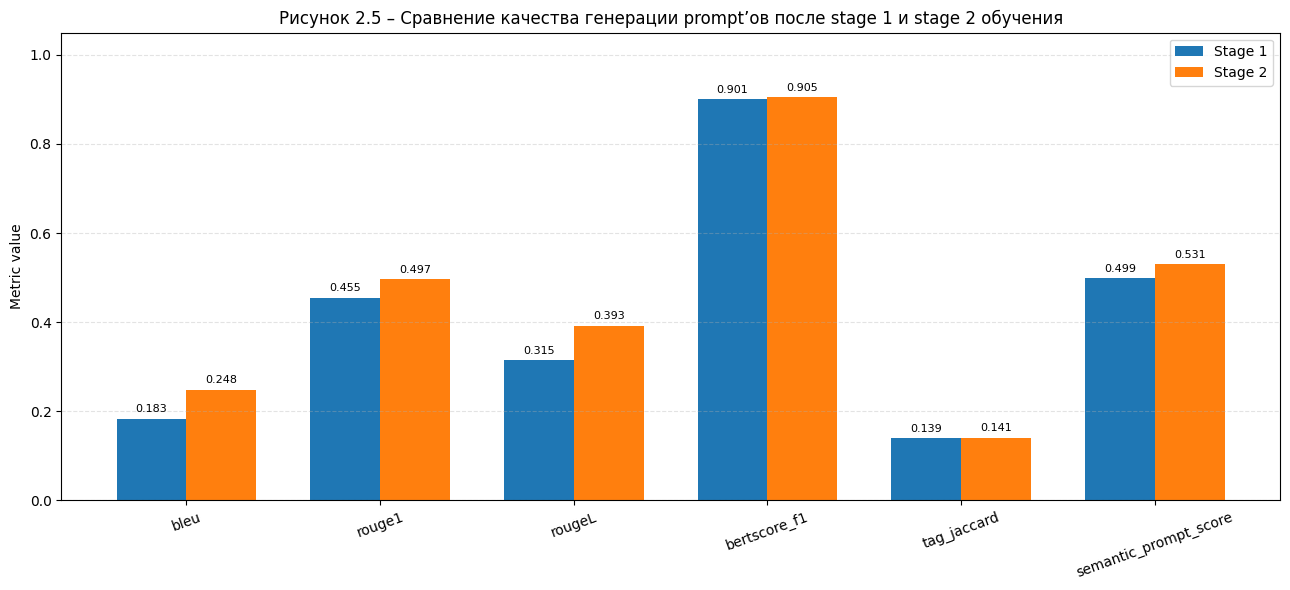

Saved: /content/artifacts/final_model_comparison/figure_2_5_stage1_vs_stage2_metrics.png


In [3]:
# =========================
# 27. STAGE 1 VS STAGE 2 график
# =========================

FIG25_METRICS = [
    "bleu",
    "rouge1",
    "rougeL",
    "bertscore_f1",
    "tag_jaccard",
    "semantic_prompt_score",
]

stage1_row = metrics_table_df[metrics_table_df["model"] == "stage1"].iloc[0]
stage2_row = metrics_table_df[metrics_table_df["model"] == "stage2"].iloc[0]

x = np.arange(len(FIG25_METRICS))
width = 0.36

plt.figure(figsize=(13, 6))
bars_1 = plt.bar(
    x - width / 2,
    [stage1_row[m] for m in FIG25_METRICS],
    width,
    label="Stage 1",
)
bars_2 = plt.bar(
    x + width / 2,
    [stage2_row[m] for m in FIG25_METRICS],
    width,
    label="Stage 2",
)

plt.xticks(x, FIG25_METRICS, rotation=20)
plt.ylim(0, 1.05)
plt.ylabel("Metric value")
plt.title("Рисунок 2.5 – Сравнение качества генерации prompt’ов после stage 1 и stage 2 обучения")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend()

for bars in (bars_1, bars_2):
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.tight_layout()
fig25_path = FINAL_REPORT_DIR / "figure_2_5_stage1_vs_stage2_metrics.png"
plt.savefig(fig25_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", fig25_path)

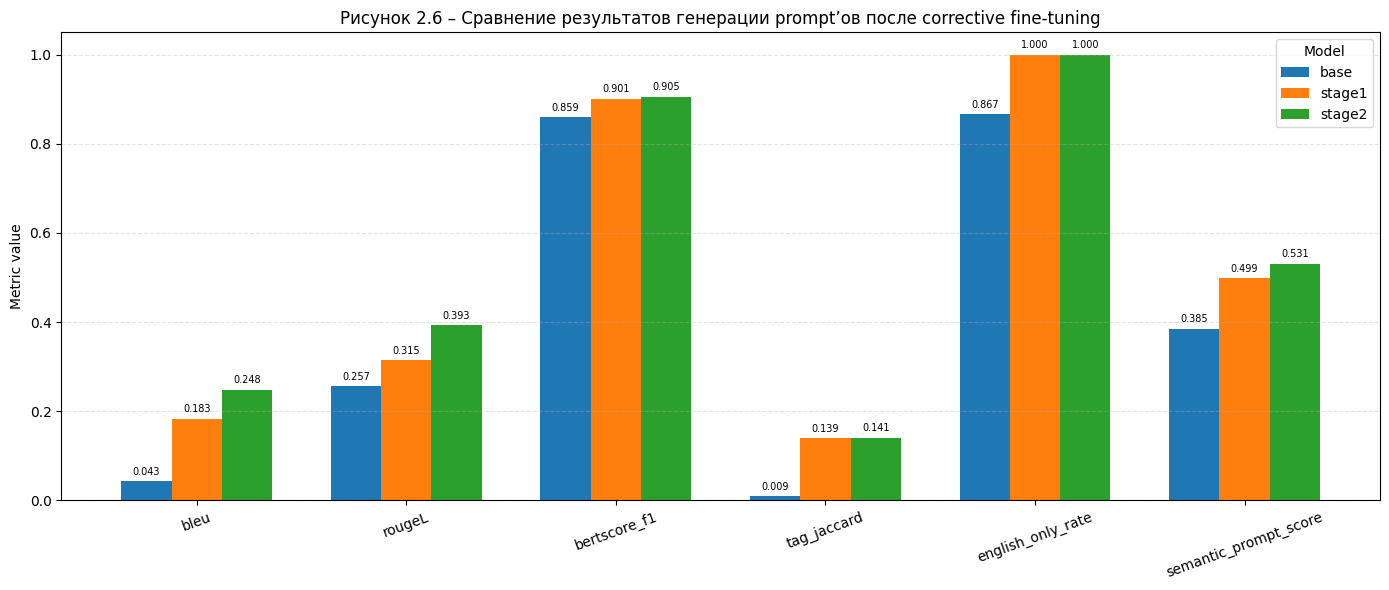

Saved: /content/artifacts/final_model_comparison/figure_2_6_base_stage1_stage2_metrics.png


In [4]:
# =========================
# 28. BASE VS STAGE1 VS STAGE2 график
# =========================

FIG26_METRICS = [
    "bleu",
    "rougeL",
    "bertscore_f1",
    "tag_jaccard",
    "english_only_rate",
    "semantic_prompt_score",
]

plot_df = metrics_table_df.set_index("model")
model_order = ["base", "stage1", "stage2"]
x = np.arange(len(FIG26_METRICS))
width = 0.24

plt.figure(figsize=(14, 6))
for idx, model_name in enumerate(model_order):
    offset = (idx - 1) * width
    values = [plot_df.loc[model_name, m] for m in FIG26_METRICS]
    bars = plt.bar(x + offset, values, width, label=model_name)
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

plt.xticks(x, FIG26_METRICS, rotation=20)
plt.ylim(0, 1.05)
plt.ylabel("Metric value")
plt.title("Рисунок 2.6 – Сравнение результатов генерации prompt’ов после corrective fine-tuning")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(title="Model")
plt.tight_layout()

fig26_path = FINAL_REPORT_DIR / "figure_2_6_base_stage1_stage2_metrics.png"
plt.savefig(fig26_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", fig26_path)